# 机床振动预测（LSTM）教学案例

**知识点简介**

机床振动预测是制造业中典型的时序预测任务，常用于设备状态监测、刀具磨损预警与质量控制。LSTM（Long Short-Term Memory）是一种适合处理长序列依赖的循环神经网络，它能在噪声较大的传感器信号中捕捉长期趋势与短期波动。

**本案例意义**

- 用简化的时序建模流程演示LSTM在“振动类信号预测”中的应用思路
- 帮助学生理解从数据准备、建模、训练到评估的完整流程
- 强调模型评估与业务解释的重要性

## 1. 环境准备与数据路径

下面的代码完成依赖导入、随机种子设置，以及数据目录检查。

In [2]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# 固定随机种子，便于教学复现实验结果
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

plt.style.use("seaborn-v0_8")

# 数据目录
DATA_DIR = r"D:\xiangmu\j7-jichuang\data"
os.makedirs(DATA_DIR, exist_ok=True)

SIM_DATA_PATH = os.path.join(DATA_DIR, "simulated_vibration.csv")
print("data dir:", DATA_DIR)
print("simulated dataset:", SIM_DATA_PATH)

data dir: D:\xiangmu\j7-jichuang\data
simulated dataset: D:\xiangmu\j7-jichuang\data\simulated_vibration.csv


## 2. 生成模拟振动数据集

本节生成一份可复现的模拟机床振动数据，并保存到指定目录，作为后续LSTM训练的数据来源。

In [3]:
# 生成模拟振动数据
n_points = 2000
t = np.arange(n_points)

# 基础周期信号 + 缓慢趋势 + 噪声
base = 0.6 * np.sin(2 * np.pi * t / 50) + 0.3 * np.sin(2 * np.pi * t / 200)
trend = 0.0005 * t
noise = 0.15 * np.random.randn(n_points)

# 模拟工况变量
speed = 1500 + 80 * np.sin(2 * np.pi * t / 300) + 30 * np.random.randn(n_points)
load = 0.7 + 0.2 * np.sin(2 * np.pi * t / 120) + 0.05 * np.random.randn(n_points)

# 振动信号（加入偶发冲击）
vibration = base + trend + noise + 0.02 * (speed - speed.mean()) + 0.6 * (load - load.mean())
spike_idx = np.random.choice(n_points, size=12, replace=False)
vibration[spike_idx] += np.random.uniform(1.5, 2.5, size=len(spike_idx))

# 组织为数据集
sim_df = pd.DataFrame({
    "time": t,
    "vibration": vibration,
    "speed": speed,
    "load": load
})

sim_df.to_csv(SIM_DATA_PATH, index=False)
print("saved:", SIM_DATA_PATH)

# 读取并查看
_df = pd.read_csv(SIM_DATA_PATH)
print("shape:", _df.shape)
display(_df.head())
print(_df.describe())

saved: D:\xiangmu\j7-jichuang\data\simulated_vibration.csv
shape: (2000, 4)


,time,vibration,speed,load
0,0,-0.410584,1479.744652,0.656825
1,1,-0.037554,1497.339833,0.708907
2,2,-0.183242,1479.577455,0.721807
3,3,0.373622,1495.784396,0.754918
4,4,-0.778890,1449.885787,0.673239


              time    vibration        speed         load
count  2000.000000  2000.000000  2000.000000  2000.000000
mean    999.500000     0.518547  1502.688730     0.700507
std     577.494589     1.407442    64.091718     0.149568
min       0.000000    -3.094923  1345.244119     0.359731
25%     499.750000    -0.516116  1449.783276     0.570241
50%     999.500000     0.541512  1505.307837     0.703998
75%    1499.250000     1.552034  1553.512665     0.829167
max    1999.000000     4.925014  1648.935860     1.053843


## 3. 构造“振动类时间序列”

这里直接使用模拟数据中的`vibration`作为目标序列，并画出原始波形。

signal length: 2000
count    2000.000000
mean        0.518547
std         1.407442
min        -3.094923
25%        -0.516116
50%         0.541512
75%         1.552034
max         4.925014
Name: vibration, dtype: float64


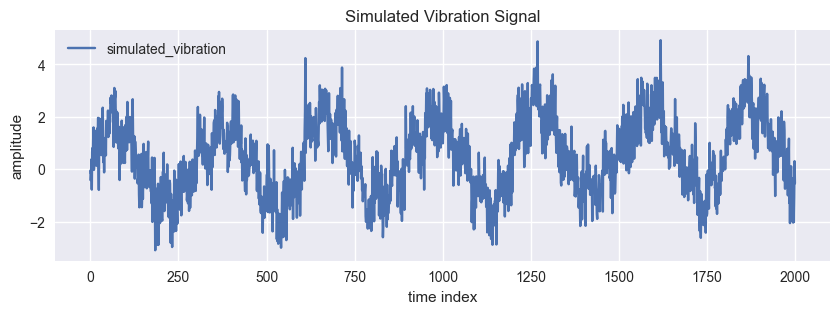

In [4]:
df = _df.copy()

signal = df["vibration"].astype(float)

print("signal length:", len(signal))
print(signal.describe())

plt.figure(figsize=(10, 3))
plt.plot(signal.values, label="simulated_vibration")
plt.title("Simulated Vibration Signal")
plt.xlabel("time index")
plt.ylabel("amplitude")
plt.legend()
plt.show()

## 4. 窗口化与数据集划分

LSTM需要固定长度的时间窗口作为输入，这里使用滑动窗口构造监督学习样本。

In [5]:
def make_sequences(series, window_size=10, horizon=1):
    X, y = [], []
    for i in range(len(series) - window_size - horizon + 1):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

# 归一化
scaler = MinMaxScaler()
series = signal.values.reshape(-1, 1)
series_scaled = scaler.fit_transform(series)

window_size = 10
horizon = 1

X, y = make_sequences(series_scaled, window_size=window_size, horizon=horizon)
print("X shape:", X.shape, "y shape:", y.shape)

# 划分训练/验证/测试
n_total = len(X)
train_end = int(n_total * 0.7)
val_end = int(n_total * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print("train/val/test:", X_train.shape, X_val.shape, X_test.shape)

X shape: (1990, 10, 1) y shape: (1990, 1)
train/val/test: (1393, 10, 1) (298, 10, 1) (299, 10, 1)


## 5. 构建LSTM模型

输入为长度为`window_size`的一维序列，输出预测下一时刻振动值。

In [6]:
model = models.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 10, 64)            16896     
                                                                 
 dropout (Dropout)           (None, 10, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 6. 训练模型

使用早停策略防止过拟合，并绘制训练过程曲线。

Epoch 1/200


88/88 [==============================] - 4s 14ms/step - loss: 0.0216 - mae: 0.1081 - val_loss: 0.0083 - val_mae: 0.0713
Epoch 2/200
88/88 [==============================] - 0s 6ms/step - loss: 0.0089 - mae: 0.0748 - val_loss: 0.0094 - val_mae: 0.0770
Epoch 3/200
88/88 [==============================] - 0s 5ms/step - loss: 0.0096 - mae: 0.0777 - val_loss: 0.0080 - val_mae: 0.0704
Epoch 4/200
88/88 [==============================] - 0s 5ms/step - loss: 0.0090 - mae: 0.0751 - val_loss: 0.0080 - val_mae: 0.0700
Epoch 5/200
88/88 [==============================] - 0s 5ms/step - loss: 0.0089 - mae: 0.0751 - val_loss: 0.0092 - val_mae: 0.0751
Epoch 6/200
88/88 [==============================] - 1s 6ms/step - loss: 0.0089 - mae: 0.0746 - val_loss: 0.0079 - val_mae: 0.0697
Epoch 7/200
88/88 [==============================] - 0s 6ms/step - loss: 0.0088 - mae: 0.0743 - val_loss: 0.0088 - val_mae: 0.0744
Epoch 8/200
88/88 [==============================] - 0s 5ms/step - loss: 0.0087 

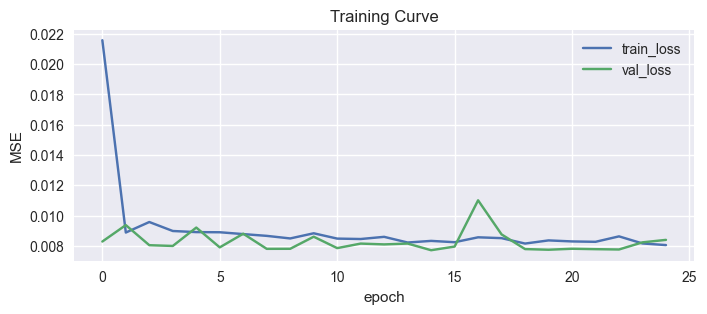

In [7]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(8, 3))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training Curve")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

## 7. 评估与可视化

计算MAE、RMSE并画出预测结果对比。

10/10 [==============================] - 1s 2ms/step
MAE: 0.5531, RMSE: 0.7055


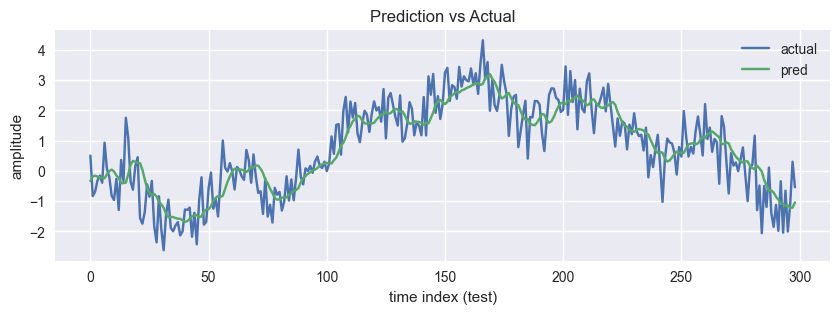

In [8]:
# 预测
pred_scaled = model.predict(X_test)

# 反归一化
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
pred_inv = scaler.inverse_transform(pred_scaled).ravel()

mae = mean_absolute_error(y_test_inv, pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")

plt.figure(figsize=(10, 3))
plt.plot(y_test_inv, label="actual")
plt.plot(pred_inv, label="pred")
plt.title("Prediction vs Actual")
plt.xlabel("time index (test)")
plt.ylabel("amplitude")
plt.legend()
plt.show()

## 8. 滚动预测未来若干步

用最后一个窗口作为起点，逐步预测未来序列。

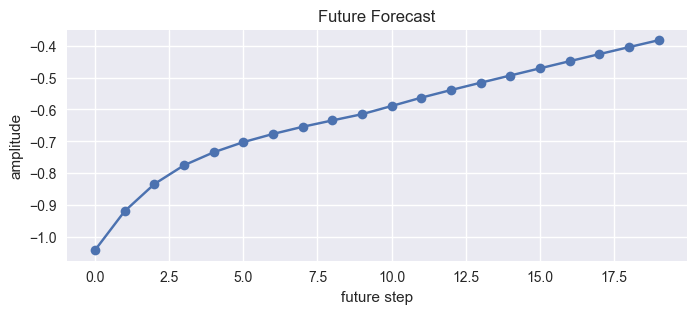

In [9]:
def rolling_forecast(model, last_window, steps=20):
    preds = []
    window = last_window.copy()
    for _ in range(steps):
        pred = model.predict(window[np.newaxis, :, :], verbose=0)[0, 0]
        preds.append(pred)
        window = np.vstack([window[1:], [[pred]]])
    return np.array(preds)

last_window = X_test[-1]
future_steps = 20
future_scaled = rolling_forecast(model, last_window, steps=future_steps)
future_inv = scaler.inverse_transform(future_scaled.reshape(-1, 1)).ravel()

plt.figure(figsize=(8, 3))
plt.plot(future_inv, marker="o")
plt.title("Future Forecast")
plt.xlabel("future step")
plt.ylabel("amplitude")
plt.show()

## 9. 拓展与思考（含解答思路）

1. **问题：如果有多通道传感器（如X/Y/Z三轴加速度），如何改造输入？**  
   思路：将输入从一维改为多维特征，形状为`(window_size, num_features)`，使用`MinMaxScaler`对每个特征归一化。

2. **问题：窗口长度对预测效果有什么影响？**  
   思路：较短窗口捕捉短期波动，较长窗口捕捉长期趋势。可用验证集比较不同窗口长度的RMSE。

3. **问题：怎样判断模型过拟合？**  
   思路：训练损失持续下降而验证损失上升；可以使用早停、增加正则化或减小模型规模。

4. **问题：如何把预测结果用于故障预警？**  
   思路：设置基于业务规则的阈值（如振动幅值或残差超过阈值持续若干步），并结合告警策略进行判定。

5. **问题：如何评估模型在真实工况中的稳健性？**  
   思路：在不同工况、不同设备上进行交叉验证或留一设备验证，观察泛化误差和稳定性。